# Histopathologic Cancer Detection Workflow

This notebook runs the project workflow while keeping the core code in scripts/modules.

Use this notebook for:
- checking the dataset and labels
- visualizing example images
- training the CNN by calling `train_model()`
- loading the saved best model
- generating `outputs/submission.csv`

The scripts stay responsible for reusable logic: data utilities, model definition, training, and prediction.

## 1. Environment setup

Run this notebook from the project root if possible. Expected structure:

```text
project/
├── data/
│   ├── train/
│   ├── test/
│   ├── train_labels.csv
│   └── sample_submission.csv
├── src/
│   ├── data_utils.py
│   ├── model.py
│   ├── train.py
│   └── predict.py
├── outputs/
└── cancer_detection_workflow.ipynb
```

If your scripts are in the same folder as the notebook instead of `src/`, the path setup below should still work.

In [1]:
# Optional install commands for a Miniconda environment.
# Run these in a terminal, not necessarily inside the notebook.
#
# conda create -n cancer-cnn python=3.11 -y
# conda activate cancer-cnn
#
# For NVIDIA GPU / CUDA, install PyTorch from the official selector for your CUDA version:
# https://pytorch.org/get-started/locally/
# Example only; adjust CUDA version as needed:
# pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
#
# Other required packages:
# pip install pandas matplotlib pillow scikit-learn tqdm jupyter ipykernel
# python -m ipykernel install --user --name cancer-cnn --display-name "Python (cancer-cnn)

In [2]:
from pathlib import Path
import sys
import os

PROJECT_ROOT = Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"

# If running from notebooks/, move project root one level up.
if not SRC_DIR.exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
    SRC_DIR = PROJECT_ROOT / "src"

# If scripts are in the same folder as the notebook, use current folder.
if not SRC_DIR.exists():
    SRC_DIR = PROJECT_ROOT

sys.path.insert(0, str(SRC_DIR))
os.makedirs(PROJECT_ROOT / "outputs", exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Source directory:", SRC_DIR)
print("Python executable:", sys.executable)

Project root: /home/jg/Desktop/AI_LAB5/histopathologic-cancer
Source directory: /home/jg/Desktop/AI_LAB5/histopathologic-cancer/src
Python executable: /home/jg/Desktop/AI_LAB5/venv/bin/python3


In [3]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 3090


## 2. Import project scripts

These imports use the existing scripts instead of copying the training code into the notebook.

In [4]:
from data_utils import load_labels, show_sample_images, plot_label_distribution
from model import DeepCustomCNN
from train import train_model
from predict import generate_submission

🚀 Using device: cuda


## 3. Check data paths

In [5]:
TRAIN_CSV = PROJECT_ROOT / "data" / "train_labels.csv"
TRAIN_DIR = PROJECT_ROOT / "data" / "train"
TEST_DIR = PROJECT_ROOT / "data" / "test"
SAMPLE_SUBMISSION = PROJECT_ROOT / "data" / "sample_submission.csv"
MODEL_PATH = PROJECT_ROOT / "outputs" / "model.pth"
SUBMISSION_PATH = PROJECT_ROOT / "outputs" / "submission.csv"

for path in [TRAIN_CSV, TRAIN_DIR, TEST_DIR, SAMPLE_SUBMISSION]:
    print(f"{path}: {path.exists()}")

/home/jg/Desktop/AI_LAB5/histopathologic-cancer/data/train_labels.csv: True
/home/jg/Desktop/AI_LAB5/histopathologic-cancer/data/train: True
/home/jg/Desktop/AI_LAB5/histopathologic-cancer/data/test: True
/home/jg/Desktop/AI_LAB5/histopathologic-cancer/data/sample_submission.csv: True


## 4. Load labels and inspect dataset

In [6]:
df = load_labels(TRAIN_CSV)
print(df.shape)
df.head()

(220025, 2)


,id,label
0,f38a6374c348f90b587e046aac6079959adf3835,0
1,c18f2d887b7ae4f6742ee445113fa1aef383ed77,1
2,755db6279dae599ebb4d39a9123cce439965282d,0
3,bc3f0c64fb968ff4a8bd33af6971ecae77c75e08,0
4,068aba587a4950175d04c680d38943fd488d6a9d,0


In [7]:
df['label'].value_counts(dropna=False)

label
0    130908
1     89117
Name: count, dtype: int64

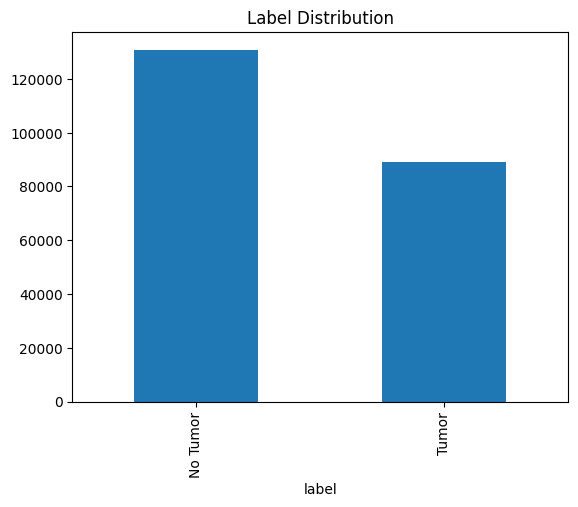

In [8]:
plot_label_distribution(df)

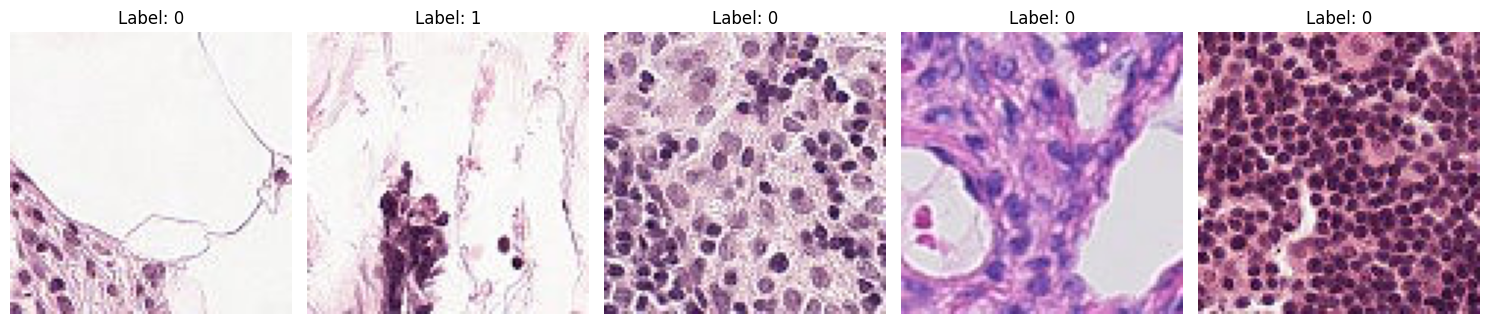

In [9]:
show_sample_images(df, TRAIN_DIR, num=5)

## 5. Optional: sanity-check the model shape

Your model resizes images to `96 x 96`. After five pooling layers, the tensor is expected to become `512 x 3 x 3`, which flattens to `4608`, matching the classifier input.

Note: `model.py` currently prints the flatten shape inside every forward pass. That is useful for debugging, but it will spam output during full training. After confirming the shape once, you may want to comment out that `print()` line in `model.py`.

In [10]:
model = DeepCustomCNN()
dummy = torch.randn(1, 3, 96, 96)
with torch.no_grad():
    out = model(dummy)
print("Output shape:", out.shape)

🧠 Flatten input shape: torch.Size([1, 512, 3, 3])
Output shape: torch.Size([1, 1])


## 6. Train the model

This calls `train_model()` from `train.py`. The function uses:
- 80/20 train-validation split
- data augmentation on training images
- validation loss monitoring
- early stopping
- saving the best model to `outputs/model.pth`

For a quick test, start with `epochs=1`. For real training, increase to something like `epochs=10` or more.

In [11]:
# Start with 1 epoch to verify the workflow.
# Then increase epochs for real training.

model = train_model(epochs=1, save_path=str(MODEL_PATH))

Epoch 1/1:   0%|                                                                                                                                           | 1/2751 [00:00<18:41,  2.45it/s, loss=0.696]

🧠 Flatten input shape: torch.Size([64, 512, 3, 3])


Epoch 1/1:   0%|▎                                                                                                                                          | 5/2751 [00:00<04:54,  9.32it/s, loss=0.671]

🧠 Flatten input shape: torch.Size([64, 512, 3, 3])
🧠 Flatten input shape: torch.Size([64, 512, 3, 3])
🧠 Flatten input shape: torch.Size([64, 512, 3, 3])
🧠 Flatten input shape: torch.Size([64, 512, 3, 3])


Epoch 1/1:   0%|▍                                                                                                                                           | 9/2751 [00:00<03:35, 12.70it/s, loss=0.69]

...

🧠 Flatten input shape: torch.Size([64, 512, 3, 3])
🧠 Flatten input shape: torch.Size([64, 512, 3, 3])
🧠 Flatten input shape: torch.Size([64, 512, 3, 3])
🧠 Flatten input shape: torch.Size([64, 512, 3, 3])


Epoch 1/1: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉| 2749/2751 [02:47<00:00, 16.69it/s, loss=0.316]

🧠 Flatten input shape: torch.Size([64, 512, 3, 3])
🧠 Flatten input shape: torch.Size([64, 512, 3, 3])
🧠 Flatten input shape: torch.Size([64, 512, 3, 3])
🧠 Flatten input shape: torch.Size([64, 512, 3, 3])


Epoch 1/1: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2751/2751 [02:47<00:00, 16.45it/s, loss=0.332]


🧠 Flatten input shape: torch.Size([64, 512, 3, 3])
🧠 Flatten input shape: torch.Size([20, 512, 3, 3])
📈 Epoch 1/1 - Avg Loss: 0.4360
⏱️ Epoch 1 took 167.23 seconds
🧠 Flatten input shape: torch.Size([64, 512, 3, 3])
🧠 Flatten input shape: torch.Size([64, 512, 3, 3])
🧠 Flatten input shape: torch.Size([64, 512, 3, 3])
🧠 Flatten input shape: torch.Size([64, 512, 3, 3])
🧠 Flatten input shape: torch.Size([64, 512, 3, 3])
🧠 Flatten input shape: torch.Size([64, 512, 3, 3])
🧠 Flatten input shape: torch.Size([64, 512, 3, 3])
🧠 Flatten input shape: torch.Size([64, 512, 3, 3])
🧠 Flatten input shape: torch.Size([64, 512, 3, 3])
🧠 Flatten input shape: torch.Size([64, 512, 3, 3])
🧠 Flatten input shape: torch.Size([64, 512, 3, 3])
🧠 Flatten input shape: torch.Size([64, 512, 3, 3])
🧠 Flatten input shape: torch.Size([64, 512, 3, 3])
🧠 Flatten input shape: torch.Size([64, 512, 3, 3])
🧠 Flatten input shape: torch.Size([64, 512, 3, 3])
🧠 Flatten input shape: torch.Size([64, 512, 3, 3])
🧠 Flatten input shap

## 7. Load the saved best model

This is useful if you trained earlier and want to generate predictions without retraining.

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

best_model = DeepCustomCNN().to(device)
best_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
best_model.eval()

print("Loaded model from:", MODEL_PATH)

Loaded model from: /home/jg/Desktop/AI_LAB5/histopathologic-cancer/outputs/model.pth


## 8. Generate test predictions / Kaggle submission

This calls `generate_submission()` from `predict.py`. It reads `sample_submission.csv`, predicts probabilities for every test image, and writes `outputs/submission.csv`.

In [13]:
generate_submission(
    model=best_model,
    test_dir=str(TEST_DIR),
    sample_csv=str(SAMPLE_SUBMISSION),
    output_csv=str(SUBMISSION_PATH)
)

🚀 Using device for prediction: cuda
🧠 Flatten input shape: torch.Size([1, 512, 3, 3])
🧠 Flatten input shape: torch.Size([1, 512, 3, 3])
🧠 Flatten input shape: torch.Size([1, 512, 3, 3])
🧠 Flatten input shape: torch.Size([1, 512, 3, 3])
🧠 Flatten input shape: torch.Size([1, 512, 3, 3])
🧠 Flatten input shape: torch.Size([1, 512, 3, 3])
🧠 Flatten input shape: torch.Size([1, 512, 3, 3])
🧠 Flatten input shape: torch.Size([1, 512, 3, 3])
🧠 Flatten input shape: torch.Size([1, 512, 3, 3])
🧠 Flatten input shape: torch.Size([1, 512, 3, 3])
🧠 Flatten input shape: torch.Size([1, 512, 3, 3])
🧠 Flatten input shape: torch.Size([1, 512, 3, 3])
🧠 Flatten input shape: torch.Size([1, 512, 3, 3])
🧠 Flatten input shape: torch.Size([1, 512, 3, 3])
🧠 Flatten input shape: torch.Size([1, 512, 3, 3])
🧠 Flatten input shape: torch.Size([1, 512, 3, 3])
🧠 Flatten input shape: torch.Size([1, 512, 3, 3])
🧠 Flatten input shape: torch.Size([1, 512, 3, 3])
🧠 Flatten input shape: torch.Size([1, 512, 3, 3])
🧠 Flatten inpu

In [ ]:
submission = pd.read_csv(SUBMISSION_PATH)
print(submission.shape)
submission.head()

In [ ]:
submission['label'].describe()

## 9. Concise explanation of project files

- `data_utils.py`: helper functions for reading labels, displaying sample images, and plotting the tumor/no-tumor label distribution.
- `model.py`: defines the PyTorch CNN architecture used for binary cancer classification.
- `train.py`: builds the PyTorch datasets/dataloaders, applies image transforms and augmentation, trains the CNN, validates it, uses early stopping, and saves the best model.
- `predict.py`: loads test images, applies the same resize/tensor preprocessing, runs the trained model, converts logits to probabilities with sigmoid, and writes the Kaggle-style submission CSV.
- This notebook: coordinates the workflow interactively, checks paths/GPU, visualizes data, calls the training script, loads the best saved model, and calls the prediction script.

## 10. Library roles

- `torch`: neural network tensors, GPU computation, loss functions, optimizer, model saving/loading.
- `torchvision`: image transforms such as resizing, flips, rotation, color jitter, and tensor conversion.
- `pandas`: reads `train_labels.csv` and `sample_submission.csv`, stores labels/predictions, writes `submission.csv`.
- `Pillow`: opens `.tif` image files.
- `matplotlib`: plots sample images and label distributions.
- `scikit-learn`: creates the stratified train/validation split.
- `tqdm`: progress bars during training.
- `jupyter` / `ipykernel`: runs this notebook inside your selected Miniconda environment.